In [1]:
import numpy as np
from numpy.polynomial import polynomial as P
from scipy import interpolate as ip
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import random
from symfit import parameters, variables, sin, cos, Fit
from scipy import signal
import pandas as pd
import os

# Fix for symfit compatibility with NumPy 2.x
np.product = np.prod

In [2]:
def create_gaussian_kernel_1d(fwhm, pz_spacing, kernel_size=None):
    """
    Create a normalized 1D Gaussian kernel for convolution.
    
    Parameters:
    - fwhm: Full Width at Half Maximum in atomic units
    - pz_spacing: spacing between pz points
    - kernel_size: size of the kernel (if None, automatically determined)
    
    Returns:
    - normalized Gaussian kernel as numpy array
    """
    # Convert FWHM to standard deviation (sigma)
    # FWHM = 2 * sqrt(2 * ln(2)) * sigma
    sigma_au = fwhm / (2 * np.sqrt(2 * np.log(2)))
    
    # Convert sigma from atomic units to number of points
    sigma_points = sigma_au / pz_spacing
    
    # Determine kernel size (6 sigma covers ~99.7% of Gaussian)
    if kernel_size is None:
        kernel_size = int(6 * sigma_points)
        # Ensure odd kernel size
        if kernel_size % 2 == 0:
            kernel_size += 1
    
    # Create Gaussian kernel
    gaussian_kernel = signal.windows.gaussian(kernel_size, std=sigma_points)
    
    # Normalize the kernel
    gaussian_kernel_normalized = gaussian_kernel / gaussian_kernel.sum()
    
    return gaussian_kernel_normalized



def add_poisson_noise_compton(profile, scale_factor=10000):
    # Ensure profile is non-negative to avoid ValueError in Poisson
    profile_safe = np.maximum(profile, 0)
    
    photon_counts = profile_safe * scale_factor
    
    # Apply Poisson noise
    noisy_photons = np.random.poisson(photon_counts)
    
    # Scale back down
    noisy_profile = noisy_photons / scale_factor
    
    # Optional: If you shifted the profile previously, handle it here
    # noisy_profile = noisy_profile + profile.min() 
    
    return noisy_profile


def degrade_compton_profile(profile, pz, fwhm=None, noise_scale=None, _kernel=None):
    """
    Degrade a Compton profile by convolution with Gaussian resolution function and adding noise.
    
    Parameters:
    - profile: clean Compton profile (numpy array)
    - pz: momentum values (numpy array)
    - fwhm: Full Width at Half Maximum of resolution function (default: 0.4 a.u. for magnetic Compton)
    - noise_scale: Poisson noise scale factor (default: 1000)
    - _kernel: precomputed Gaussian kernel (skips kernel creation if provided)
    
    Returns:
    - degraded profile as numpy array
    """
    if _kernel is not None:
        kernel = _kernel
    else:
        # Calculate pz spacing
        pz_spacing = pz[1] - pz[0]
        # Create Gaussian kernel
        kernel = create_gaussian_kernel_1d(fwhm, pz_spacing)
    
    # Convolve profile with kernel (mode='same' keeps same length)
    convolved_profile = np.convolve(profile, kernel, mode='same')
    
    # calculate errors
    std_errors = np.sqrt(convolved_profile * noise_scale) / noise_scale  # Poisson error scaled back to profile units
    
    # Add Poisson noise
    degraded_profile = add_poisson_noise_compton(convolved_profile, scale_factor=noise_scale)
    
    return degraded_profile, std_errors

In [3]:
from scipy.optimize import minimize_scalar

def normalise(pz, cp, area_under_curve=1):
    """
    Normalise the Compton profile by integrating over pz to a specific area.
    """
    current_area = np.trapz(cp, pz)
    # Normalize to area = 1, then scale up to the desired area under curve
    return (cp / current_area) * area_under_curve 

def gaussian(x, amplitude, sigma):
    """
    Proper Gaussian function for curve fitting.
    
    Parameters:
    - x: input array
    - amplitude: amplitude/height of the Gaussian
    - sigma: standard deviation (width parameter)
    """
    return amplitude * np.exp(-x**2 / (2 * sigma**2))


def g_model(x, *args):
    """
    Fits data with sum of three Gaussians (no polynomial).
    Parameters are flattened: 
    - args[0:6]: 3 Gaussians, each with (amplitude, sigma) = 6 params
    Total: 6 parameters
    """
    arr = np.zeros(x.shape)
    # Sum of 3 Gaussians
    for i in range(3):
        arr += gaussian(x, *args[i*2:i*2+2])
    return arr

def fourier_series(x, f, n=0, f_0 = 0.4):
    """
    Returns a symbolic Fourier series of order `n`.

    :param n: Order of the Fourier series.
    :param x: Independent variable
    :param f: Frequency of the Fourier series
    """
    # Make the parameter objects for all the terms
    a0, *cos_a = parameters(','.join(['a{}'.format(i) for i in range(0, n + 1)]))
    sin_b = parameters(','.join(['b{}'.format(i) for i in range(1, n + 1)]))
    # Construct the series
    series = a0 + sum(ai * cos(i * f *f_0 * x) + bi * sin(i * f *f_0 * x)
    for i, (ai, bi) in enumerate(zip(cos_a, sin_b), start=1))
    return series


def _fourier_design_matrix(pz, w, fourier_order, f_0=1.0):
    """Build design matrix for Fourier series: a0 + sum(ai*cos + bi*sin)."""
    n = len(pz)
    ncols = 1 + 2 * fourier_order
    A = np.empty((n, ncols), dtype=np.float64)
    A[:, 0] = 1.0
    for k in range(1, fourier_order + 1):
        angle = k * w * f_0 * pz
        A[:, 2*k - 1] = np.cos(angle)
        A[:, 2*k] = np.sin(angle)
    return A


def _fit_fourier_fast(pz, residuals, fourier_order, fourier_steps=1, w_bounds=(0.1, 5.0)):
    """
    Fit Fourier series to residuals using numpy lstsq (linear coefficients)
    + scalar optimization for the single nonlinear frequency parameter w.
    ~100-1000x faster than symfit.
    """
    f_0 = 1.0 / fourier_steps

    def _objective(w_val):
        A = _fourier_design_matrix(pz, w_val, fourier_order, f_0)
        coeffs, _, _, _ = np.linalg.lstsq(A, residuals, rcond=None)
        return np.sum((residuals - A @ coeffs)**2)

    w_result = minimize_scalar(_objective, bounds=w_bounds, method='bounded')
    w_opt = w_result.x

    A_final = _fourier_design_matrix(pz, w_opt, fourier_order, f_0)
    coeffs, _, _, _ = np.linalg.lstsq(A_final, residuals, rcond=None)

    # Pack into dict matching the original fourier_params format
    params = {'w': w_opt, 'a0': coeffs[0]}
    for k in range(1, fourier_order + 1):
        params[f'a{k}'] = coeffs[2*k - 1]
        params[f'b{k}'] = coeffs[2*k]

    fourier_fit_raw = A_final @ coeffs
    return params, fourier_fit_raw, w_result.fun


def fit_theoretical_profile(pz, cp, n_gaussians=3, fourier_order=40, fourier_strength=25, 
                            initial_guesses=None, verbose=True, fourier_steps=1):
    """
    Fit a theoretical Compton profile with Gaussians + Fourier series for residuals.
    Uses fast numpy least-squares instead of symfit for the Fourier part.
    """
    # Set default initial guesses if not provided
    if initial_guesses is None:
        if n_gaussians == 3:
            initial_guesses = [(0.8, 0.5), (0.2, 1.5), (0.1, 3.0)]
        else:
            initial_guesses = [(0.8 / (i+1), 0.5 * (i+1)) for i in range(n_gaussians)]
    
    # Flatten initial guess list
    p0 = [p for prms in initial_guesses for p in prms]
    
    # Define bounds for parameters
    lower_bounds = [0.0, 0.1] * n_gaussians
    upper_bounds = [1.0, 10.0] * n_gaussians
    
    # Create temporary model function for this specific n_gaussians
    def temp_model(x, *args):
        arr = np.zeros(x.shape)
        for i in range(n_gaussians):
            arr += gaussian(x, *args[i*2:i*2+2])
        return arr
    
    # Fit Gaussians using curve_fit
    popt, pcov = curve_fit(temp_model, pz, cp, p0,
                           bounds=(lower_bounds, upper_bounds),
                           method='trf',
                           max_nfev=1000000)
    
    # Reconstruct Gaussian fit
    gauss_fit = np.zeros(cp.shape)
    gauss_params = []
    for i in range(n_gaussians):
        amplitude, sigma = popt[i*2], popt[i*2+1]
        gauss_fit += gaussian(pz, amplitude, sigma)
        gauss_params.append((amplitude, sigma))
        
        if verbose:
            print(f'Gaussian {i+1}: Amplitude = {amplitude:.4f}, Sigma = {sigma:.4f}')
    
    # Calculate residuals
    residuals = cp - gauss_fit
    
    # Fast Fourier series fit (replaces symfit — orders of magnitude faster)
    fourier_params, fourier_fit_raw, rss = _fit_fourier_fast(
        pz, residuals, fourier_order, fourier_steps=fourier_steps
    )
    
    if verbose:
        print(f'\nFourier Series Fit (fast):')
        print(f'  w = {fourier_params["w"]:.6f}, RSS = {rss:.6e}')
    
    fourier_fit_scaled = fourier_fit_raw * fourier_strength * gauss_fit
    
    # Complete fit (Gaussian + scaled Fourier)
    complete_fit = gauss_fit + fourier_fit_scaled 
    
    return {
        'gauss_params': gauss_params,
        'gauss_fit': gauss_fit,
        'fourier_params': fourier_params,
        'fourier_strength': fourier_strength,
        'fourier_fit': fourier_fit_scaled,
        'fourier_fit_raw': fourier_fit_raw,
        'complete_fit': complete_fit,
        'residuals': residuals,
        'popt': popt,
        'pcov': pcov
    }


def GenerateSyntheticProfile(pz, gauss_params, fourier_params, fourier_order=None, FWHM=None, noise_scale=None, fourier_strength=None, fourier_steps=1):
    def get_param_value(param):
        return param.value if hasattr(param, 'value') else param

    # Gaussian component
    gauss_profile = np.zeros_like(pz)
    for amplitude, sigma in gauss_params:
        gauss_profile += gaussian(pz, amplitude, sigma)

    # Fourier component
    a0_val = get_param_value(fourier_params['a0'])
    w_val = get_param_value(fourier_params['w'])
    fourier_profile = a0_val * np.ones_like(pz)
    
    # Recreate the base frequency scaling factor used during the symfit execution
    f_0 = 1 / fourier_steps
    
    for i in range(1, fourier_order + 1):
        ai_val = get_param_value(fourier_params[f'a{i}'])
        bi_val = get_param_value(fourier_params[f'b{i}'])
        # Use consistent frequency scaling identical to fit_theoretical_profile
        fourier_profile += ai_val * np.cos(i * w_val * f_0 * pz) + bi_val * np.sin(i * w_val * f_0 * pz)
    
    fourier_profile_scaled = fourier_profile * fourier_strength * gauss_profile
    
    # Combine as in fit_theoretical_profile
    synthetic_profile = np.array(gauss_profile) + np.array(fourier_profile_scaled)        

    synthetic_profile_degraded, _ = degrade_compton_profile(synthetic_profile, pz, fwhm=FWHM, noise_scale=noise_scale)

    
    return normalise(pz, synthetic_profile), normalise(pz, synthetic_profile_degraded)


def build_synthetic_training_dataset_from_fits(
    pz,
    base_profiles,
    n_profiles=1000,
    n_gaussians=3,
    fourier_order=10,
    base_fourier_strength=20,
    fourier_strength_range=(0.8, 1.2),
    input_jitter_std=0.01,
    FWHM=0.12,
    peak_count=200000,
    random_seed=42,
    max_attempt_factor=20,
    verbose=True,
    normalise_area=1,
    reject_negative=True,
    return_fit_results=False,
):
    """
    Build synthetic training data by repeatedly fitting perturbed theoretical profiles,
    using `complete_fit` as the generated clean profile, then degrading it.

    Returns:
    - clean_profiles_np: shape (N, len(pz))
    - degraded_profiles_np: shape (N, len(pz))
    - fit_results_list (optional)
    """
    rng = np.random.default_rng(random_seed)
    pz = np.asarray(pz, dtype=np.float64)
    base_profiles = [np.asarray(cp, dtype=np.float64) for cp in base_profiles]

    # Precompute the Gaussian degradation kernel once (same FWHM & pz spacing throughout)
    pz_spacing = pz[1] - pz[0]
    deg_kernel = create_gaussian_kernel_1d(FWHM, pz_spacing)

    clean_profiles = []
    degraded_profiles = []
    fit_results_list = []

    attempts = 0
    max_attempts = int(n_profiles * max_attempt_factor)

    import time
    t0 = time.perf_counter()

    while len(clean_profiles) < n_profiles and attempts < max_attempts:
        attempts += 1

        # Randomly choose one theoretical profile and apply a mild perturbation
        base_cp = base_profiles[rng.integers(0, len(base_profiles))]
        cp_for_fit = base_cp * (1.0 + rng.normal(0.0, input_jitter_std, size=base_cp.shape))
        cp_for_fit = np.clip(cp_for_fit, a_min=0.0, a_max=None)

        strength_scale = rng.uniform(fourier_strength_range[0], fourier_strength_range[1])
        fourier_strength = base_fourier_strength * strength_scale

        fit_result = fit_theoretical_profile(
            pz,
            cp_for_fit,
            n_gaussians=n_gaussians,
            fourier_order=fourier_order,
            fourier_strength=fourier_strength,
            verbose=False,
        )

        generated_clean = np.asarray(fit_result['complete_fit'], dtype=np.float64)

        # Skip invalid profiles and keep generating until dataset is full
        if reject_negative and np.any(generated_clean < 0):
            continue
        if not np.isfinite(generated_clean).all():
            continue

        if normalise_area is not None:
            generated_clean = normalise(pz, generated_clean, area_under_curve=normalise_area)

        peak_val = generated_clean.max()
        if peak_val <= 0:
            continue

        noise_scale = peak_count / peak_val
        generated_degraded, _ = degrade_compton_profile(
            generated_clean,
            pz,
            fwhm=FWHM,
            noise_scale=noise_scale,
            _kernel=deg_kernel,
        )

        if normalise_area is not None:
            generated_degraded = normalise(pz, generated_degraded, area_under_curve=normalise_area)

        clean_profiles.append(generated_clean.astype(np.float32))
        degraded_profiles.append(generated_degraded.astype(np.float32))
        fit_results_list.append(fit_result)

        if verbose and len(clean_profiles) % 100 == 0:
            elapsed = time.perf_counter() - t0
            rate = len(clean_profiles) / elapsed
            print(f"Generated {len(clean_profiles)}/{n_profiles} profiles  "
                  f"[{elapsed:.1f}s elapsed, {rate:.1f} profiles/s]")

    if len(clean_profiles) < n_profiles:
        raise RuntimeError(
            f"Only generated {len(clean_profiles)} valid profiles out of requested {n_profiles}. "
            f"Try increasing max_attempt_factor or loosening constraints."
        )

    elapsed = time.perf_counter() - t0
    if verbose:
        print(f"Done: {n_profiles} profiles in {elapsed:.1f}s ({n_profiles/elapsed:.1f} profiles/s)")

    clean_profiles_np = np.stack(clean_profiles)
    degraded_profiles_np = np.stack(degraded_profiles)

    if return_fit_results:
        return clean_profiles_np, degraded_profiles_np, fit_results_list
    return clean_profiles_np, degraded_profiles_np

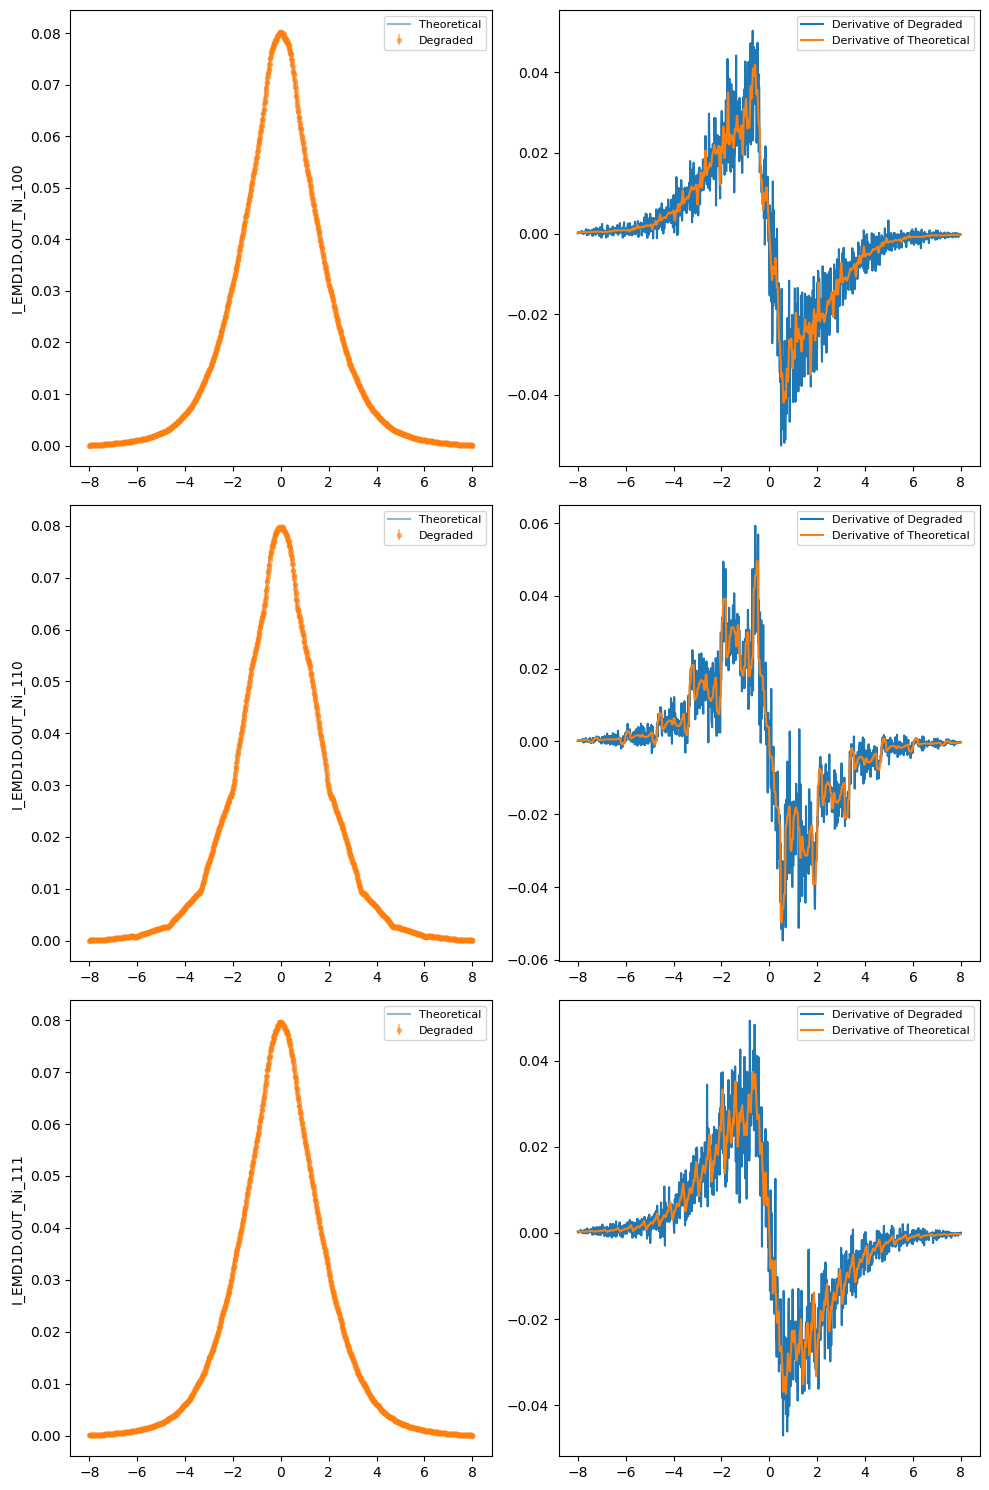

In [4]:
%matplotlib inline
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Configuration
peak_count = 200000
FWHM = 0.12
folder_path = "Ni_degen_spin"  # Updated to match your file structure 

# Get list of files and filter out any hidden system files
filenames = [f for f in os.listdir(folder_path) if not f.startswith('.')]
num_files = len(filenames)

# Initialize plots based on actual file count
fig, ax = plt.subplots(num_files, 2, figsize=(10, num_files * 5)) 
#ax.set_title("Theoretical Profiles")
#ax[1].set_title("Derivative of Theoretical Profiles")

dataframes = {}

for i, filename in enumerate(filenames):
    file_path = os.path.join(folder_path, filename)
    
    # Load data: using sep='\s+' for whitespace-separated values and skipping headers [cite: 2]
    dataframes[filename] = pd.read_csv(file_path, names=['p_z', 'Theory J(p_z)'], sep='\s+', skiprows=1)
    
    # Calculate Theoretical Gradient
    dataframes[filename]["Theory dJ(p_z)"] = np.gradient(dataframes[filename]['Theory J(p_z)'], dataframes[filename]['p_z'])
    
    # Find peak and set noise scale
    peak_val = dataframes[filename]['Theory J(p_z)'].max()
    noise_scale = peak_count / peak_val
    
    # Degrade profile using your helper function
    dataframes[filename]["Degraded Theory J(p_z)"], dataframes[filename]["Degraded Theory J(p_z) errors"] = degrade_compton_profile(
        dataframes[filename]["Theory J(p_z)"].values, 
        dataframes[filename]["p_z"].values, 
        fwhm=FWHM, 
        noise_scale=noise_scale
    )
    
    # Take derivative of degraded profile
    dataframes[filename]["Degraded Theory dJ(p_z)"] = np.gradient(dataframes[filename]["Degraded Theory J(p_z)"], dataframes[filename]['p_z'])
    
    # Plotting
    ax[i, 0].plot(dataframes[filename]['p_z'], dataframes[filename]['Theory J(p_z)'], label='Theoretical', alpha=0.5)
    ax[i, 0].errorbar(dataframes[filename]['p_z'], dataframes[filename]['Degraded Theory J(p_z)'], 
                      yerr=dataframes[filename]["Degraded Theory J(p_z) errors"], fmt='o', markersize=3, label='Degraded', alpha=0.5)
    
    ax[i, 1].plot(dataframes[filename]['p_z'], dataframes[filename]['Degraded Theory dJ(p_z)'], label='Derivative of Degraded')
    ax[i, 1].plot(dataframes[filename]['p_z'], dataframes[filename]['Theory dJ(p_z)'], label='Derivative of Theoretical')
    
    ax[i, 0].set_ylabel(filename) # Added label to identify which Ni file is being plotted
    ax[i, 0].legend(fontsize=8, loc='best')
    ax[i, 1].legend(fontsize=8, loc='best')

fig.tight_layout()
plt.show()

In [5]:
pz = dataframes[filenames[0]]['p_z'].values
profile0 = dataframes[filenames[0]]["Theory J(p_z)"].values
profile1 = dataframes[filenames[1]]["Theory J(p_z)"].values

fourier_order = 12
fourier_strength = 30
fit_result1 = fit_theoretical_profile(pz, profile0, n_gaussians=3, fourier_order=fourier_order, fourier_strength=fourier_strength, verbose=True)
fit_result2 = fit_theoretical_profile(pz, profile1, n_gaussians=3, fourier_order=fourier_order, fourier_strength=fourier_strength, verbose=True)

Gaussian 1: Amplitude = 0.0166, Sigma = 0.5537
Gaussian 2: Amplitude = 0.0481, Sigma = 1.5018
Gaussian 3: Amplitude = 0.0162, Sigma = 2.5185

Fourier Series Fit (fast):
  w = 0.652805, RSS = 2.502188e-05
Gaussian 1: Amplitude = 0.0094, Sigma = 0.3818
Gaussian 2: Amplitude = 0.0390, Sigma = 1.2267
Gaussian 3: Amplitude = 0.0323, Sigma = 2.1847

Fourier Series Fit (fast):
  w = 3.113683, RSS = 4.617152e-04


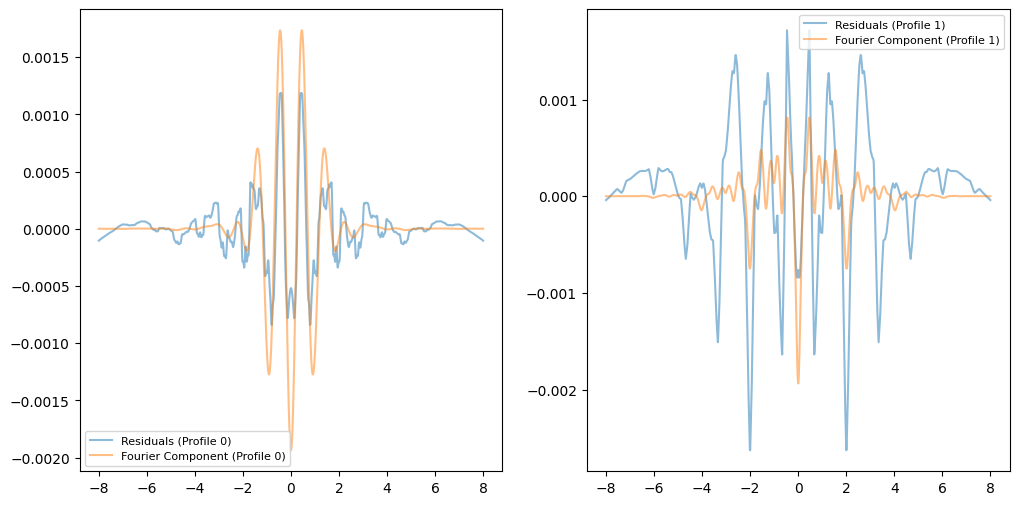

In [6]:
%matplotlib inline
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].plot(pz, profile0-fit_result1['gauss_fit'], label='Residuals (Profile 0)', alpha=0.5)
ax[0].plot(pz, fit_result1['fourier_fit'], label='Fourier Component (Profile 0)', alpha=0.5)
ax[0].legend(fontsize=8, loc='best')

ax[1].plot(pz, profile1-fit_result2['gauss_fit'], label='Residuals (Profile 1)', alpha=0.5)
ax[1].plot(pz, fit_result2['fourier_fit'], label='Fourier Component (Profile 1)', alpha=0.5)
ax[1].legend(fontsize=8, loc='best')

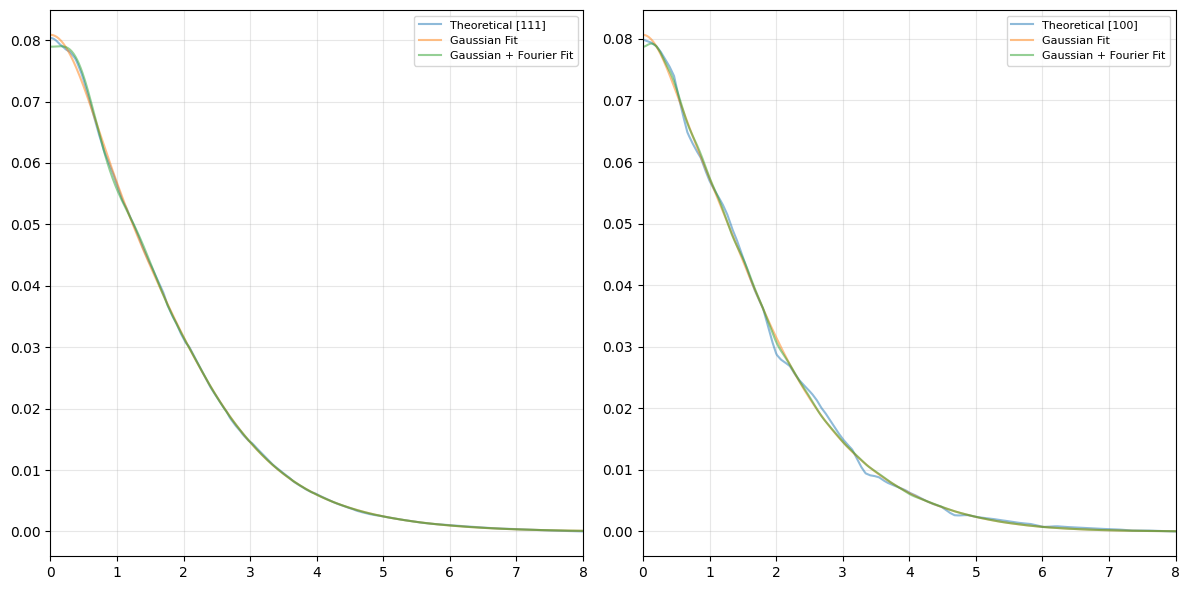

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

axs[0].plot(pz, profile0, label='Theoretical [111]', alpha=0.5)
axs[0].plot(pz, fit_result1['gauss_fit'], label='Gaussian Fit', alpha=0.5)
axs[0].plot(pz, fit_result1['complete_fit'], label='Gaussian + Fourier Fit', alpha=0.5)
axs[0].legend(fontsize=8, loc='best')
axs[0].grid(True, alpha=0.3)
axs[0].set_xlim(0, pz.max())

axs[1].plot(pz, profile1, label='Theoretical [100]', alpha=0.5)
axs[1].plot(pz, fit_result2['gauss_fit'], label='Gaussian Fit', alpha=0.5)
axs[1].plot(pz, fit_result2['complete_fit'], label='Gaussian + Fourier Fit', alpha=0.5)
axs[1].legend(fontsize=8, loc='best')
axs[1].grid(True, alpha=0.3)
axs[1].set_xlim(0, pz.max())
fig.tight_layout()

In [8]:
fourier_spread = 2
gauss_spread = 2
N_profiles = 1000
sample_every = 1
fourier_strength_variation = 0.02  # Allow Fourier strength to vary by ±0.2%

# Calculate differences in Gaussian parameters between the two profiles
gauss_difference = np.array(fit_result1['gauss_params']) - np.array(fit_result2['gauss_params'])

# Calculate differences in Fourier parameters between the two profiles
fourier_1 = fit_result1['fourier_params']
fourier_2 = fit_result2['fourier_params']
odd_sucess = 0
even_sucess = 0
fourier_difference = {}
for param_name in fourier_1.keys():
    diff = fourier_1[param_name] - fourier_2[param_name]
    fourier_difference[param_name] = diff

# Generate N_profiles synthetic profiles with randomized parameters
clean_profiles = []
degraded_profiles = []
attempts = 0
max_attempts = N_profiles * 10  # Prevent infinite loop

while len(clean_profiles) < N_profiles and attempts < max_attempts:
    attempts += 1
    
    # Create test Gaussian parameters by randomly varying the original parameters
    test_gauss_params = []
    for i in range(3):
        amp_diff = gauss_difference[i][0]
        sigma_diff = gauss_difference[i][1]
        
        # Randomly vary the parameters within a certain spread
        amp_variation = random.uniform(-gauss_spread, gauss_spread) * amp_diff * fourier_spread
        sigma_variation = random.uniform(-gauss_spread, gauss_spread) * sigma_diff * fourier_spread
        
        if attempts % 2 == 0:
            test_amp = fit_result1['gauss_params'][i][0] + amp_variation
            test_sigma = fit_result1['gauss_params'][i][1] + sigma_variation
        else:
            test_amp = fit_result2['gauss_params'][i][0] + amp_variation
            test_sigma = fit_result2['gauss_params'][i][1] + sigma_variation
        
        test_gauss_params.append((test_amp, test_sigma))
    
    # Create test Fourier parameters by randomly varying the original parameters
    test_fourier_params = {}
    if attempts % 2 == 0:
        fourier_base = fourier_1
    else:
        fourier_base = fourier_2
    for param_name in fourier_base.keys():
        original_value = fourier_base[param_name]
        diff = fourier_difference[param_name]
        
        # Randomly vary the parameter within a certain spread
        variation = random.uniform(-fourier_spread, fourier_spread) * diff * fourier_spread
        test_fourier_params[param_name] = original_value + variation
    
    # Generate the synthetic profile
    #print(noise)
    fourier_strength_variation_factor = 1 + random.uniform(-fourier_strength_variation, fourier_strength_variation)
    test_fourier_strength = fourier_strength * fourier_strength_variation_factor
    test_profile, degraded_profile = GenerateSyntheticProfile(pz, test_gauss_params, test_fourier_params, fourier_order=fourier_order, FWHM = FWHM, noise_scale = noise_scale, fourier_strength = test_fourier_strength)
    if test_profile is not None and degraded_profile is not None:
        clean_profiles.append(test_profile[::sample_every])
        degraded_profiles.append(degraded_profile[::sample_every])
        if attempts % 2 == 0:
            even_sucess += 1
        else:
            odd_sucess += 1
print("Even attempts successful:", even_sucess)
print("Odd attempts successful:", odd_sucess)
print(f"Generated {len(clean_profiles)} valid synthetic profiles (out of {attempts} attempts)")


C:\Users\Jpjha\AppData\Local\Temp\ipykernel_34408\2829822014.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  current_area = np.trapz(cp, pz)
C:\Users\Jpjha\AppData\Local\Temp\ipykernel_34408\2769223466.py:81: RuntimeWarning: invalid value encountered in sqrt
  std_errors = np.sqrt(convolved_profile * noise_scale) / noise_scale  # Poisson error scaled back to profile units
C:\Users\Jpjha\AppData\Local\Temp\ipykernel_34408\2829822014.py:9: RuntimeWarning: invalid value encountered in divide
  return (cp / current_area) * area_under_curve


Even attempts successful: 500
Odd attempts successful: 500
Generated 1000 valid synthetic profiles (out of 1000 attempts)


In [9]:
# Build training dataset from fit_theoretical_profile -> complete_fit -> degraded profile

base_profiles = [df['Theory J(p_z)'].values for df in dataframes.values()]

clean_profiles_np, degraded_profiles_np = build_synthetic_training_dataset_from_fits(
    pz=pz,
    base_profiles=base_profiles,
    n_profiles=4000,
    n_gaussians=3,
    fourier_order=fourier_order,
    base_fourier_strength=fourier_strength,
    FWHM=FWHM,
    peak_count=peak_count,
    random_seed=42,
    reject_negative=True,
    verbose=True,
)

print('clean_profiles_np shape:', clean_profiles_np.shape)
print('degraded_profiles_np shape:', degraded_profiles_np.shape)

# Use these for ML training
clean_profiles = [row for row in clean_profiles_np]
degraded_profiles = [row for row in degraded_profiles_np]

C:\Users\Jpjha\AppData\Local\Temp\ipykernel_34408\2829822014.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  current_area = np.trapz(cp, pz)


Generated 100/4000 profiles  [3.7s elapsed, 27.0 profiles/s]
Generated 200/4000 profiles  [7.4s elapsed, 27.1 profiles/s]
Generated 300/4000 profiles  [11.0s elapsed, 27.2 profiles/s]
Generated 400/4000 profiles  [14.5s elapsed, 27.7 profiles/s]
Generated 500/4000 profiles  [18.0s elapsed, 27.8 profiles/s]
Generated 600/4000 profiles  [21.9s elapsed, 27.5 profiles/s]
Generated 700/4000 profiles  [26.5s elapsed, 26.5 profiles/s]
Generated 800/4000 profiles  [30.2s elapsed, 26.5 profiles/s]
Generated 900/4000 profiles  [34.0s elapsed, 26.5 profiles/s]
Generated 1000/4000 profiles  [37.4s elapsed, 26.8 profiles/s]
Generated 1100/4000 profiles  [40.9s elapsed, 26.9 profiles/s]
Generated 1200/4000 profiles  [44.4s elapsed, 27.1 profiles/s]
Generated 1300/4000 profiles  [48.1s elapsed, 27.0 profiles/s]
Generated 1400/4000 profiles  [51.8s elapsed, 27.0 profiles/s]
Generated 1500/4000 profiles  [55.4s elapsed, 27.1 profiles/s]
Generated 1600/4000 profiles  [59.9s elapsed, 26.7 profiles/s]
Gen

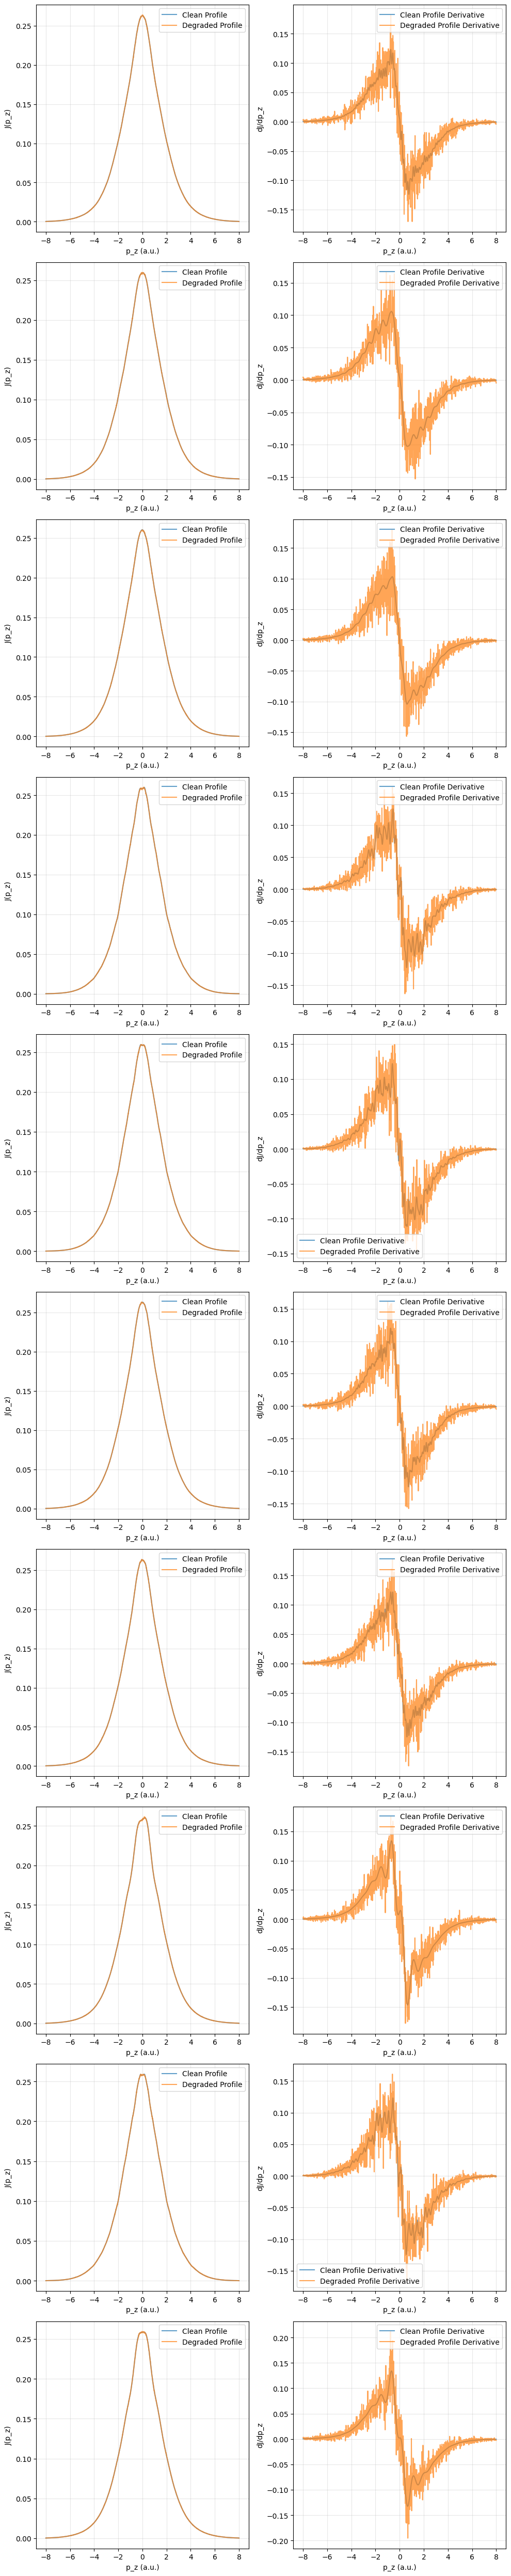

In [10]:

pz_sample = pz[::sample_every]
fig, ax = plt.subplots(len(clean_profiles[:10]), 2, figsize=(10, 50))

for i, (clean_profile, degraded_profile) in enumerate(zip(clean_profiles[:10], degraded_profiles[:10])):
    ax[i, 0].plot(pz_sample, clean_profile, label='Clean Profile', alpha=0.7)
    ax[i, 0].plot(pz_sample, degraded_profile, label='Degraded Profile', alpha=0.7)
    # plot the derivatives
    ax[i, 1].plot(pz_sample, np.gradient(clean_profile, pz_sample), label='Clean Profile Derivative', alpha=0.7)
    ax[i, 1].plot(pz_sample, np.gradient(degraded_profile, pz_sample), label='Degraded Profile Derivative', alpha=0.7)
    
    ax[i, 0].legend()
    ax[i, 1].legend()
    ax[i, 0].set_xlabel('p_z (a.u.)')
    ax[i, 1].set_xlabel('p_z (a.u.)')
    ax[i, 0].set_ylabel('J(p_z)')
    ax[i, 1].set_ylabel('dJ/dp_z')
    ax[i, 0].grid(True, alpha=0.3)
    ax[i, 1].grid(True, alpha=0.3)

fig.tight_layout()

In [11]:
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split

In [12]:
class DeblurCNN(nn.Module):
    """
    Basic CNN encoder-decoder for Compton profile deconvolution.
    """
    def __init__(self):
        super(DeblurCNN, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=7, padding=3),
            nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(128, 256, kernel_size=5, padding=2),
            nn.ReLU(),
        )
        
        self.decoder = nn.Sequential(
            nn.Conv1d(256, 128, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(128, 64, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(64, 1, kernel_size=7, padding=3),
        )
    
    def forward(self, x):
        # x shape: (batch_size, signal_length)
        x = x.unsqueeze(1)  # Add channel dimension
        x = self.encoder(x)
        x = self.decoder(x)
        return x.squeeze(1)  # Remove channel dimension


In [40]:
def prepare_train_test_data(clean_profiles, degraded_profiles, test_size=0.2, seed=42):
    """
    Prepare training and testing data from profile lists.
    
    Parameters:
    - clean_profiles: list of clean profile arrays
    - degraded_profiles: list of degraded profile arrays
    - test_size: fraction of data to use for testing
    - seed: random seed for reproducibility
    
    Returns:
    - X_train, X_test, y_train, y_test as PyTorch tensors
    """
    # Stack profiles into arrays
    X = np.stack(degraded_profiles)  # Degraded profiles (inputs)    
    y = np.stack(clean_profiles)     # Clean profiles (targets)
    
    # Split into train/test
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=seed
    )
    
    # Convert to PyTorch tensors
    X_train = torch.FloatTensor(X_train)
    X_test = torch.FloatTensor(X_test)
    y_train = torch.FloatTensor(y_train)
    y_test = torch.FloatTensor(y_test)
    
    return X_train, X_test, y_train, y_test


def train_model_cnn(model, X_train, y_train, X_test, y_test, 
                    epochs=100, batch_size=16, lr=0.001):
    """
    Train the CNN model with MSE loss and dual-metric early stopping.
    """
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    test_losses = []
    
    # Early Stopping Parameters
    best_train_loss = float('inf')
    best_test_loss = float('inf')
    train_patience_counter = 0
    test_patience_counter = 0
    
    train_patience = 10
    test_patience = 10
    
    # Create data loader
    train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
    train_loader = torch.utils.data.DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True
    )
    
    for epoch in range(epochs):
        # --- Training phase ---
        model.train()
        running_train_loss = 0.0
        
        for inputs, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item() * inputs.size(0)
        
        avg_train_loss = running_train_loss / len(X_train)
        train_losses.append(avg_train_loss)
        
        # --- Evaluation phase ---
        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test)
            avg_test_loss = criterion(test_outputs, y_test).item()
            test_losses.append(avg_test_loss)
        
        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss}, Test Loss: {avg_test_loss}')

        # --- Early Stopping Logic ---
        
        # 1. Check Training Loss Improvement
        if avg_train_loss < best_train_loss:
            best_train_loss = avg_train_loss
            train_patience_counter = 0
        else:
            train_patience_counter += 1
            
        # 2. Check Test Loss Improvement
        if avg_test_loss < best_test_loss:
            best_test_loss = avg_test_loss
            test_patience_counter = 0
        else:
            test_patience_counter += 1
            
        # Trigger Break
        if train_patience_counter >= train_patience:
            print(f"Early stopping triggered: Training loss hasn't improved in {train_patience} epochs.")
            break
            
        if test_patience_counter >= test_patience:
            print(f"Early stopping triggered: Test loss hasn't improved in {test_patience} epochs.")
            break
    
    return train_losses, test_losses


def train_model_unet(model, X_train, y_train, X_test, y_test,
                     epochs=300, batch_size=32, lr=1e-4,
                     derivative_weight=0.1, patience=40):
    criterion = DeconvLoss(derivative_weight=derivative_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    # Halve LR if val loss doesn't improve for 15 epochs
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=15, verbose=True
    )

    train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
    train_loader  = torch.utils.data.DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True
    )

    train_losses, test_losses = [], []
    best_test_loss = float('inf')
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        running = 0.0
        for inputs, targets in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(inputs), targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            running += loss.item() * inputs.size(0)

        avg_train = running / len(X_train)
        model.eval()
        with torch.no_grad():
            avg_test = criterion(model(X_test), y_test).item()

        scheduler.step(avg_test)
        train_losses.append(avg_train)
        test_losses.append(avg_test)

        if (epoch + 1) % 10 == 0:
            lr_now = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch+1:4d} | Train {avg_train:.6f} | Val {avg_test:.6f} | LR {lr_now:.2e}")

        if avg_test < best_test_loss:
            best_test_loss = avg_test
            patience_counter = 0
            torch.save(model.state_dict(), 'best_unet.pt')  # save best weights
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stop at epoch {epoch+1}")
                break

    # Reload best weights
    model.load_state_dict(torch.load('best_unet.pt'))
    return train_losses, test_losses



def visualize_training(train_losses, test_losses):
    """
    Visualize training and test losses over epochs.
    """
    epochs = range(1, len(train_losses) + 1)
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
    ax.plot(epochs, test_losses, 'r-', label='Test Loss', linewidth=2)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('MSE Loss', fontsize=12)
    ax.set_yscale('log')
    ax.set_title('Training and Test Loss Over Time', fontsize=14)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"\nFinal Training Loss: {train_losses[-1]:.6f}")
    print(f"Final Test Loss: {test_losses[-1]:.6f}")

In [14]:

print(len(clean_profiles[0]), len(degraded_profiles[0]))

# Prepare train/test split
X_train, X_test, y_train, y_test = prepare_train_test_data(
    clean_profiles, 
    degraded_profiles, 
    test_size=0.2, 
    seed=42
)

print(f"\nTraining set: {X_train.shape} -> {y_train.shape}")
print(f"Test set: {X_test.shape} -> {y_test.shape}")

1201 1201

Training set: torch.Size([3200, 1201]) -> torch.Size([3200, 1201])
Test set: torch.Size([800, 1201]) -> torch.Size([800, 1201])


Training U-Net model for Compton profile deconvolution...
Epoch [1/75], Train Loss: 0.0026218072218762243, Test Loss: 1.6288182450807653e-05
Epoch [2/75], Train Loss: 4.907756135708041e-06, Test Loss: 2.0374543510115473e-06
Epoch [3/75], Train Loss: 1.0740066190351171e-06, Test Loss: 4.038937504446949e-07
Epoch [4/75], Train Loss: 2.2617475053721137e-07, Test Loss: 1.287033626340417e-07
Epoch [5/75], Train Loss: 9.397125829480046e-08, Test Loss: 7.097953158563541e-08
Epoch [6/75], Train Loss: 6.157453885435871e-08, Test Loss: 5.068024933052584e-08
Epoch [7/75], Train Loss: 4.8111209309809054e-08, Test Loss: 4.333126213396099e-08
Epoch [8/75], Train Loss: 4.2254776655425986e-08, Test Loss: 3.76916133859595e-08
Epoch [9/75], Train Loss: 3.893939734211927e-08, Test Loss: 3.5275867560358165e-08
Epoch [10/75], Train Loss: 3.985500967473854e-08, Test Loss: 3.455732056067973e-08
Epoch [11/75], Train Loss: 3.660324244592061e-08, Test Loss: 4.430887656781124e-08
Epoch [12/75], Train Loss: 4.043

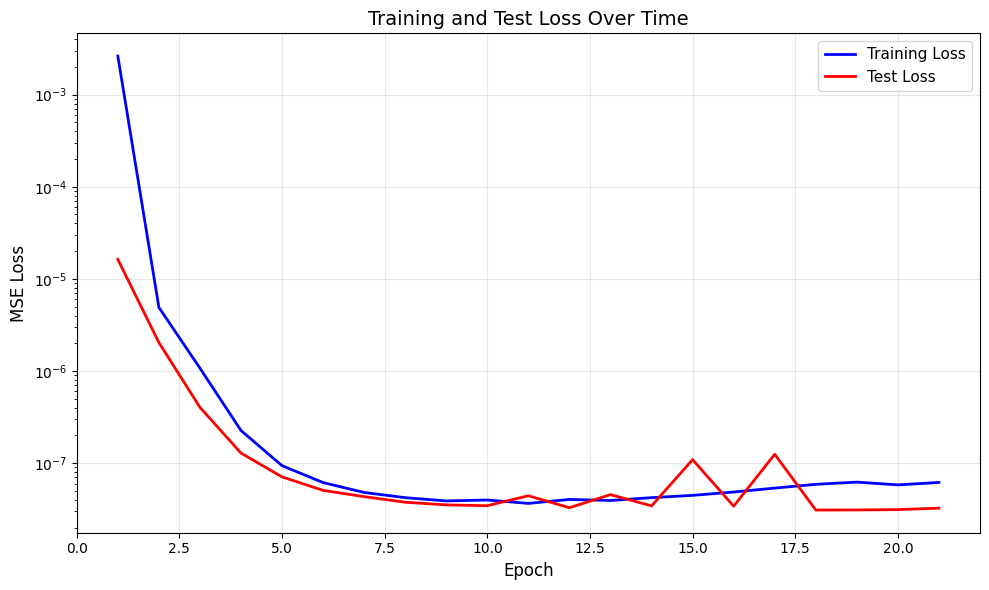


Final Training Loss: 0.000000
Final Test Loss: 0.000000


In [15]:
# Create U-Net model
model_CNN = DeblurCNN()

# Train the model
print("Training U-Net model for Compton profile deconvolution...")
print("=" * 60)

train_losses, test_losses = train_model_cnn(
    model=model_CNN,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    epochs=75,
    batch_size=32,
    lr=0.00003
)

# Visualize training progress
visualize_training(train_losses, test_losses)

train_losses, test_losses = train_model_cnn(
    model=model,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    epochs=100,
    batch_size=3,
    lr=0.000003 #0.00001 was a bit too big
)


TEST SET EVALUATION
Number of test samples: 800
Average MSE: 0.000000
Average MAE: 0.000107
Std MSE: 0.000000
Min MSE: 0.000000
Max MSE: 0.000000


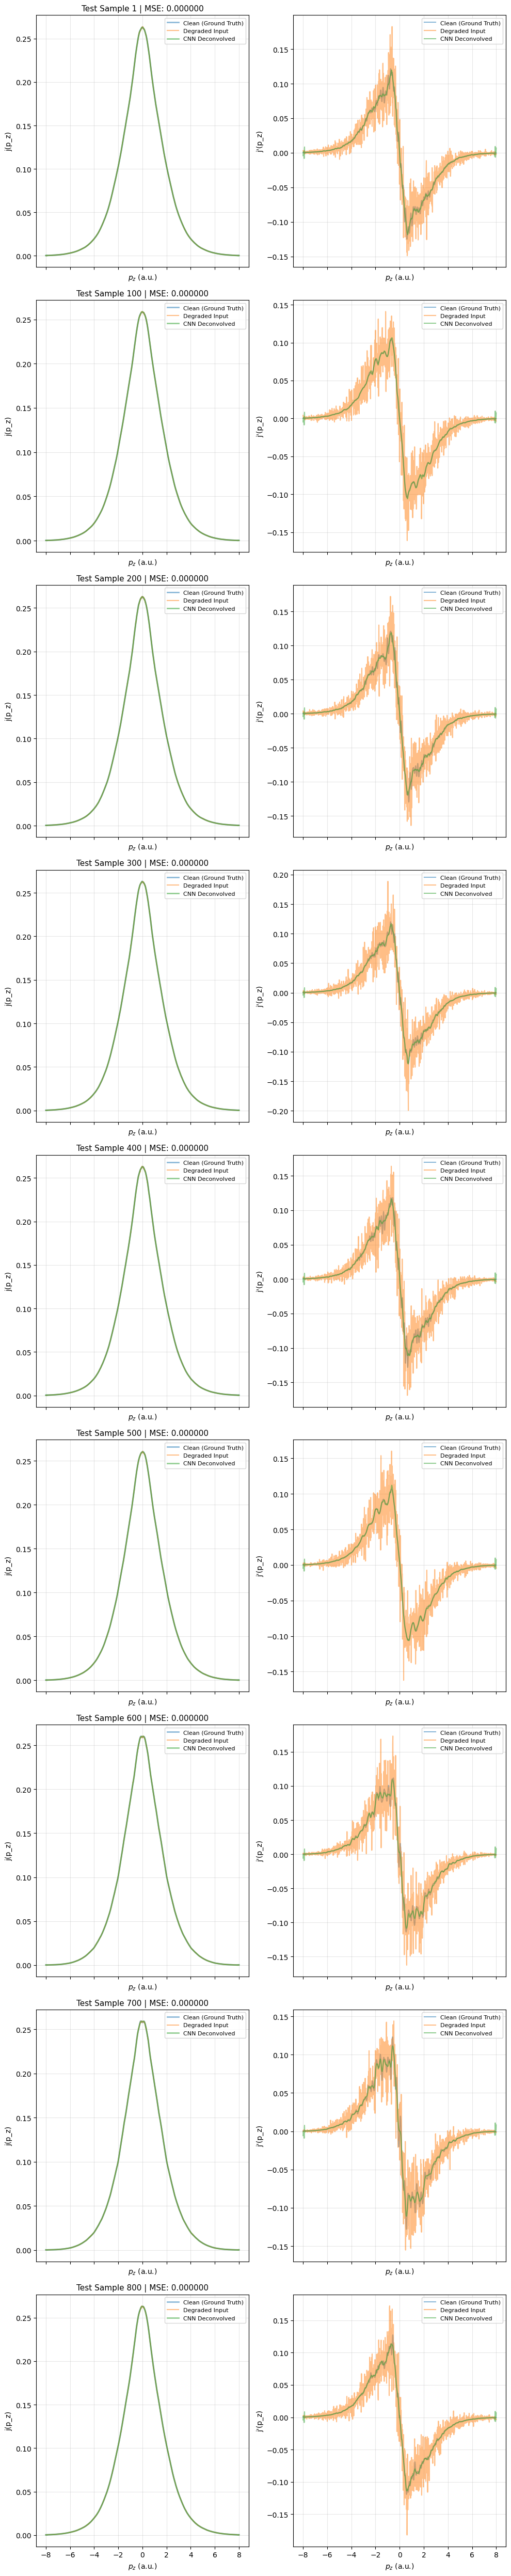

In [16]:
%matplotlib inline
# Evaluate on test set
model_CNN.eval()

with torch.no_grad():
    # Get predictions for all test samples
    test_predictions = model_CNN(X_test).numpy()
    test_clean = y_test.numpy()
    test_degraded = X_test.numpy()
    
    # Calculate metrics
    mse_per_sample = np.mean((test_predictions - test_clean)**2, axis=1)
    mae_per_sample = np.mean(np.abs(test_predictions - test_clean), axis=1)
    
    print("\n" + "=" * 60)
    print("TEST SET EVALUATION")
    print("=" * 60)
    print(f"Number of test samples: {len(test_predictions)}")
    print(f"Average MSE: {np.mean(mse_per_sample):.6f}")
    print(f"Average MAE: {np.mean(mae_per_sample):.6f}")
    print(f"Std MSE: {np.std(mse_per_sample):.6f}")
    print(f"Min MSE: {np.min(mse_per_sample):.6f}")
    print(f"Max MSE: {np.max(mse_per_sample):.6f}")
    print("=" * 60)

# Plot 9 examples from test set
fig, axs = plt.subplots(9, 2, figsize=(10, 50), sharex=True)


n_display = min(9, len(test_predictions))
display_indices = np.linspace(0, len(test_predictions)-1, n_display, dtype=int)

for i, idx in enumerate(display_indices):
    axs[i,0].plot(pz_sample, test_clean[idx], label='Clean (Ground Truth)', 
            linewidth=2, alpha=0.5)
    axs[i,0].plot(pz_sample, test_degraded[idx], label='Degraded Input', 
            linewidth=1.5, alpha=0.5)
    axs[i,0].plot(pz_sample, test_predictions[idx], label='CNN Deconvolved', 
            linewidth=2, alpha=0.5)
    
    axs[i,0].set_title(f'Test Sample {idx+1} | MSE: {mse_per_sample[idx]:.6f}', 
                fontsize=11)
    axs[i,0].set_xlabel('$p_z$ (a.u.)', fontsize=10)
    axs[i,0].set_ylabel('j(p_z)', fontsize=10)
    axs[i,0].legend(fontsize=8, loc='best')
    axs[i,0].grid(True, alpha=0.3)
    
    # plot derivatives
    axs[i,1].plot(pz_sample, np.gradient(test_clean[idx], pz_sample), label='Clean (Ground Truth)', alpha = 0.5)
    axs[i,1].plot(pz_sample, np.gradient(test_degraded[idx], pz_sample), label='Degraded Input', alpha = 0.5)
    axs[i,1].plot(pz_sample, np.gradient(test_predictions[idx], pz_sample), label='CNN Deconvolved', alpha = 0.5)
    axs[i,1].set_xlabel('$p_z$ (a.u.)', fontsize=10)
    axs[i,1].set_ylabel("j'(p_z)", fontsize=10)
    axs[i,1].legend(fontsize=8, loc='best')
    axs[i,1].grid(True, alpha=0.3)
    

plt.tight_layout()
plt.show()

C:\Users\Jpjha\AppData\Local\Temp\ipykernel_34408\2829822014.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  current_area = np.trapz(cp, pz)


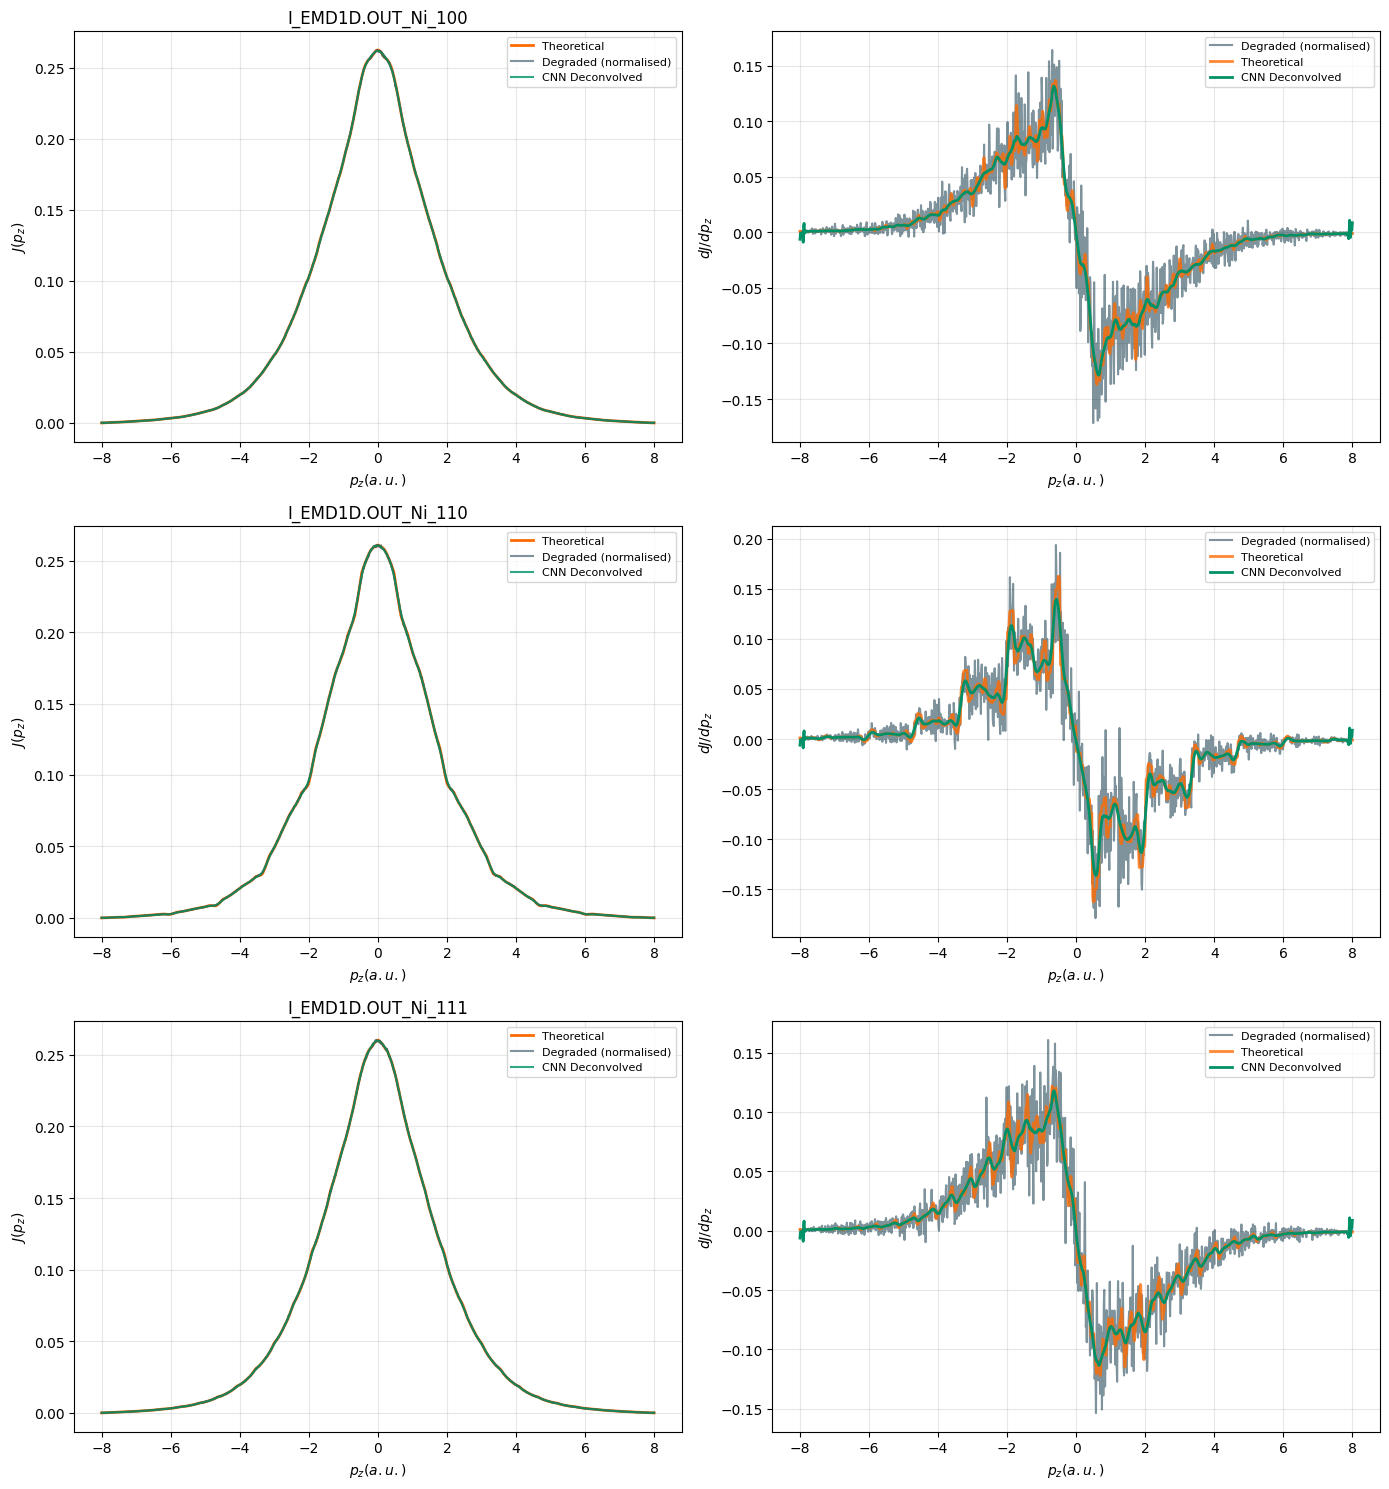

In [17]:
%matplotlib inline
model_CNN.eval()

fig, axs = plt.subplots(len(dataframes), 2, figsize=(14, 5 * len(dataframes)))
if len(dataframes) == 1:
    axs = axs[np.newaxis, :]

with torch.no_grad():
    for i, (key, df) in enumerate(dataframes.items()):
        pz_local = df['p_z'].values
        theoretical = df['Theory J(p_z)'].values
        degraded = df['Degraded Theory J(p_z)'].values

        # Normalise the degraded profile before feeding into the model
        degraded_norm = normalise(pz_local, degraded, area_under_curve=1)

        # Pass through model
        input_tensor = torch.FloatTensor(degraded_norm).unsqueeze(0)
        deconvolved = model_CNN(input_tensor).squeeze(0).numpy()

        # Also normalise theoretical for fair comparison
        theoretical_norm = normalise(pz_local, theoretical, area_under_curve=1)

        # Plot profiles
        axs[i, 0].plot(pz_local, theoretical_norm, color = "#ff6a00", label='Theoretical', linewidth=2)
        axs[i, 0].plot(pz_local, degraded_norm, color = "#00293c", label='Degraded (normalised)', alpha=0.5)
        axs[i, 0].plot(pz_local, deconvolved, color = "#009168", label='CNN Deconvolved', linewidth=1.5, alpha=0.8)
        axs[i, 0].set_title(key, fontsize=12)
        axs[i, 0].set_xlabel('$p_z (a.u.)$')
        axs[i, 0].set_ylabel('$J(p_z)$')
        axs[i, 0].legend(fontsize=8)
        axs[i, 0].grid(True, alpha=0.3)

        # Plot derivatives
        axs[i, 1].plot(pz_local, np.gradient(degraded_norm, pz_local), color = "#00293c", alpha=0.5, label='Degraded (normalised)')
        axs[i, 1].plot(pz_local, np.gradient(theoretical_norm, pz_local), color = "#ff6a00", label='Theoretical', linewidth=2, alpha = 0.8)
        axs[i, 1].plot(pz_local, np.gradient(deconvolved, pz_local), color = "#009168", label='CNN Deconvolved', linewidth=2, alpha=1)
        axs[i, 1].set_xlabel('$p_z (a.u.)$')
        axs[i, 1].set_ylabel("$dJ/dp_z$")
        axs[i, 1].legend(fontsize=8)
        axs[i, 1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

In [18]:
# use this cell for the loss metric

# U-net

In [19]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    """(Conv1d => BatchNorm1d => ReLU) * 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv1d(out_channels, out_channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class Down(nn.Module):
    """Downscaling with maxpool then double conv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool1d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

class Up(nn.Module):
    """Upscaling then double conv, with dimension matching for odd sizes like 2401"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        # Transposed convolution for upsampling
        self.up = nn.ConvTranspose1d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        
        # Grab specifically the 3rd dimension (Length) at index 2
        diff = x2.size(2) - x1.size(2) 
        
        # Pad the upsampled tensor to match the skip connection (x2)
        x1 = F.pad(x1, [diff // 2, diff - diff // 2])
        
        # Concatenate skip connection
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class AdaptedDeblurUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super(AdaptedDeblurUNet, self).__init__()
        
        # Encoder (Downsampling)
        self.inc = DoubleConv(in_channels, 32)
        self.down1 = Down(32, 64)
        self.down2 = Down(64, 128)
        self.down3 = Down(128, 256)
        
        # Decoder (Upsampling)
        self.up1 = Up(256, 128)
        self.up2 = Up(128, 64)
        self.up3 = Up(64, 32)
        
        # Final convolution to map back to 1 channel
        self.outc = nn.Conv1d(32, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder Pathway
        original_x = x.unsqueeze(1) # Output: (B, 1, 2401)
        
        x1 = self.inc(original_x)   # Output: (B, 32, 2401)
        x2 = self.down1(x1)         # Output: (B, 64, 1200)
        x3 = self.down2(x2)         # Output: (B, 128, 600)
        x4 = self.down3(x3)         # Output: (B, 256, 300) - Bottleneck
        
        # Decoder Pathway
        d = self.up1(x4, x3)        # Output: (B, 128, 600)
        d = self.up2(d, x2)         # Output: (B, 64, 1200)
        d = self.up3(d, x1)         # Output: (B, 32, 2401)
        
        residual = self.outc(d)     # Output: (B, 1, 2401)
        
        # Squeeze back to (Batch, Length)
        residual = residual.squeeze(1)
        
        # FIX: Use 'x' instead of 'original_x' so shapes match: (B, L) + (B, L)
        output = x + residual 
        
        return output

Epoch   10 | Train 0.000017 | Val 0.003751 | LR 1.00e-04
Epoch   20 | Train 0.000007 | Val 0.001249 | LR 1.00e-04
Epoch   30 | Train 0.000004 | Val 0.000586 | LR 1.00e-04
Epoch   40 | Train 0.000003 | Val 0.000317 | LR 1.00e-04
Epoch   50 | Train 0.000002 | Val 0.000120 | LR 1.00e-04
Epoch   60 | Train 0.000002 | Val 0.000023 | LR 1.00e-04
Epoch   70 | Train 0.000001 | Val 0.000005 | LR 1.00e-04
Epoch   80 | Train 0.000001 | Val 0.000003 | LR 1.00e-04
Epoch   90 | Train 0.000001 | Val 0.000002 | LR 1.00e-04
Epoch  100 | Train 0.000001 | Val 0.000002 | LR 1.00e-04
Epoch  110 | Train 0.000001 | Val 0.000001 | LR 1.00e-04
Epoch  120 | Train 0.000001 | Val 0.000002 | LR 1.00e-04
Epoch  130 | Train 0.000000 | Val 0.000001 | LR 5.00e-05
Epoch  140 | Train 0.000001 | Val 0.000001 | LR 5.00e-05
Epoch  150 | Train 0.000000 | Val 0.000001 | LR 5.00e-05
Epoch  160 | Train 0.000000 | Val 0.000001 | LR 2.50e-05
Epoch  170 | Train 0.000000 | Val 0.000000 | LR 2.50e-05
Epoch  180 | Train 0.000000 | V

C:\Users\Jpjha\AppData\Local\Temp\ipykernel_34408\3742500642.py:75: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_unet.pt'))


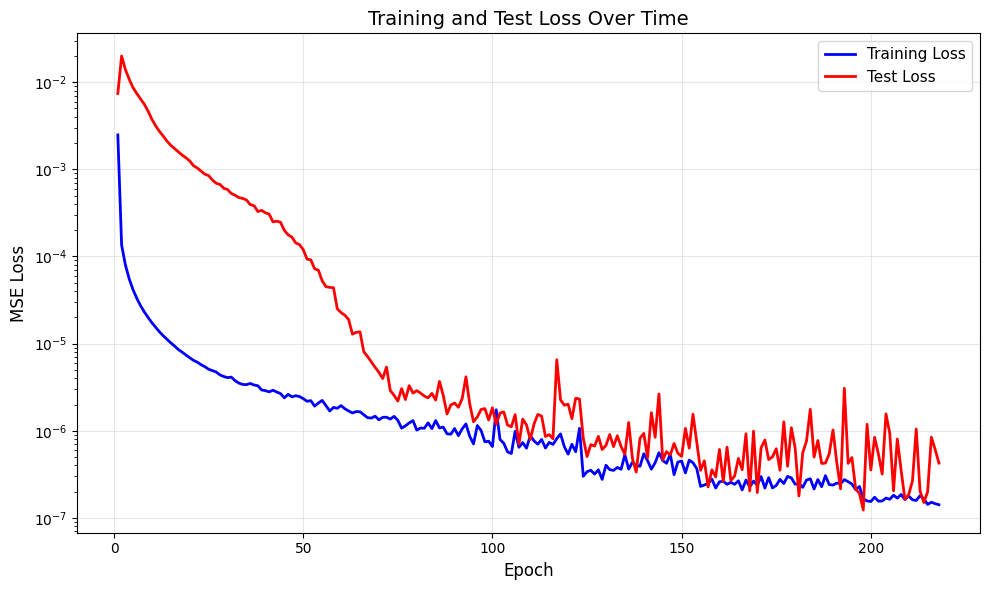


Final Training Loss: 0.000000
Final Test Loss: 0.000000


In [43]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# --- Composite loss: MSE + derivative penalty ---
class DeconvLoss(nn.Module):
    def __init__(self, derivative_weight=0.1):
        super().__init__()
        self.derivative_weight = derivative_weight
        self.mse = nn.MSELoss()

    def forward(self, pred, target):
        mse_loss = self.mse(pred, target)
        # Penalise noisy first-differences (proxy for derivative)
        pred_diff  = pred[:, 1:] - pred[:, :-1]
        target_diff = target[:, 1:] - target[:, :-1]
        deriv_loss = self.mse(pred_diff, target_diff)
        return mse_loss + self.derivative_weight * deriv_loss


def train_model_unet(model, X_train, y_train, X_test, y_test,
                     epochs=300, batch_size=32, lr=1e-4,
                     derivative_weight=0.1, patience=40):
    criterion = DeconvLoss(derivative_weight=derivative_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    # Halve LR if val loss doesn't improve for 15 epochs
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=15, verbose=True
    )

    train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
    train_loader  = torch.utils.data.DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True
    )

    train_losses, test_losses = [], []
    best_test_loss = float('inf')
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        running = 0.0
        for inputs, targets in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(inputs), targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            running += loss.item() * inputs.size(0)

        avg_train = running / len(X_train)
        model.eval()
        with torch.no_grad():
            avg_test = criterion(model(X_test), y_test).item()

        scheduler.step(avg_test)
        train_losses.append(avg_train)
        test_losses.append(avg_test)

        if (epoch + 1) % 10 == 0:
            lr_now = optimizer.param_groups[0]['lr']
            print(f"Epoch {epoch+1:4d} | Train {avg_train:.6f} | Val {avg_test:.6f} | LR {lr_now:.2e}")

        if avg_test < best_test_loss:
            best_test_loss = avg_test
            patience_counter = 0
            torch.save(model.state_dict(), 'best_unet.pt')  # save best weights
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stop at epoch {epoch+1}")
                break

    # Reload best weights
    model.load_state_dict(torch.load('best_unet.pt'))
    return train_losses, test_losses


# --- Usage ---
model_unet = AdaptedDeblurUNet()
train_losses, test_losses = train_model_unet(
    model_unet, X_train, y_train, X_test, y_test,
    epochs=300,
    batch_size=32,
    lr=1e-4,                 # ← was 3e-7, now 1e-4
    derivative_weight=0.1,   # tune this: higher = smoother output
    patience=20             # ← was 5, now 20
)
visualize_training(train_losses, test_losses)

In [41]:
model_unet = AdaptedDeblurUNet()

# Train the model
print("Training U-Net model for Compton profile deconvolution...")
print("=" * 60)

train_losses, test_losses = train_model_unet(
    model=model_unet,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    epochs=200,
    batch_size=32,
    lr=0.001
)

# Visualize training progress
visualize_training(train_losses, test_losses)

Training U-Net model for Compton profile deconvolution...


NameError: name 'DeconvLoss' is not defined


TEST SET EVALUATION
Number of test samples: 800
Average MSE: 0.000000
Average MAE: 0.000225
Std MSE: 0.000000
Min MSE: 0.000000
Max MSE: 0.000000


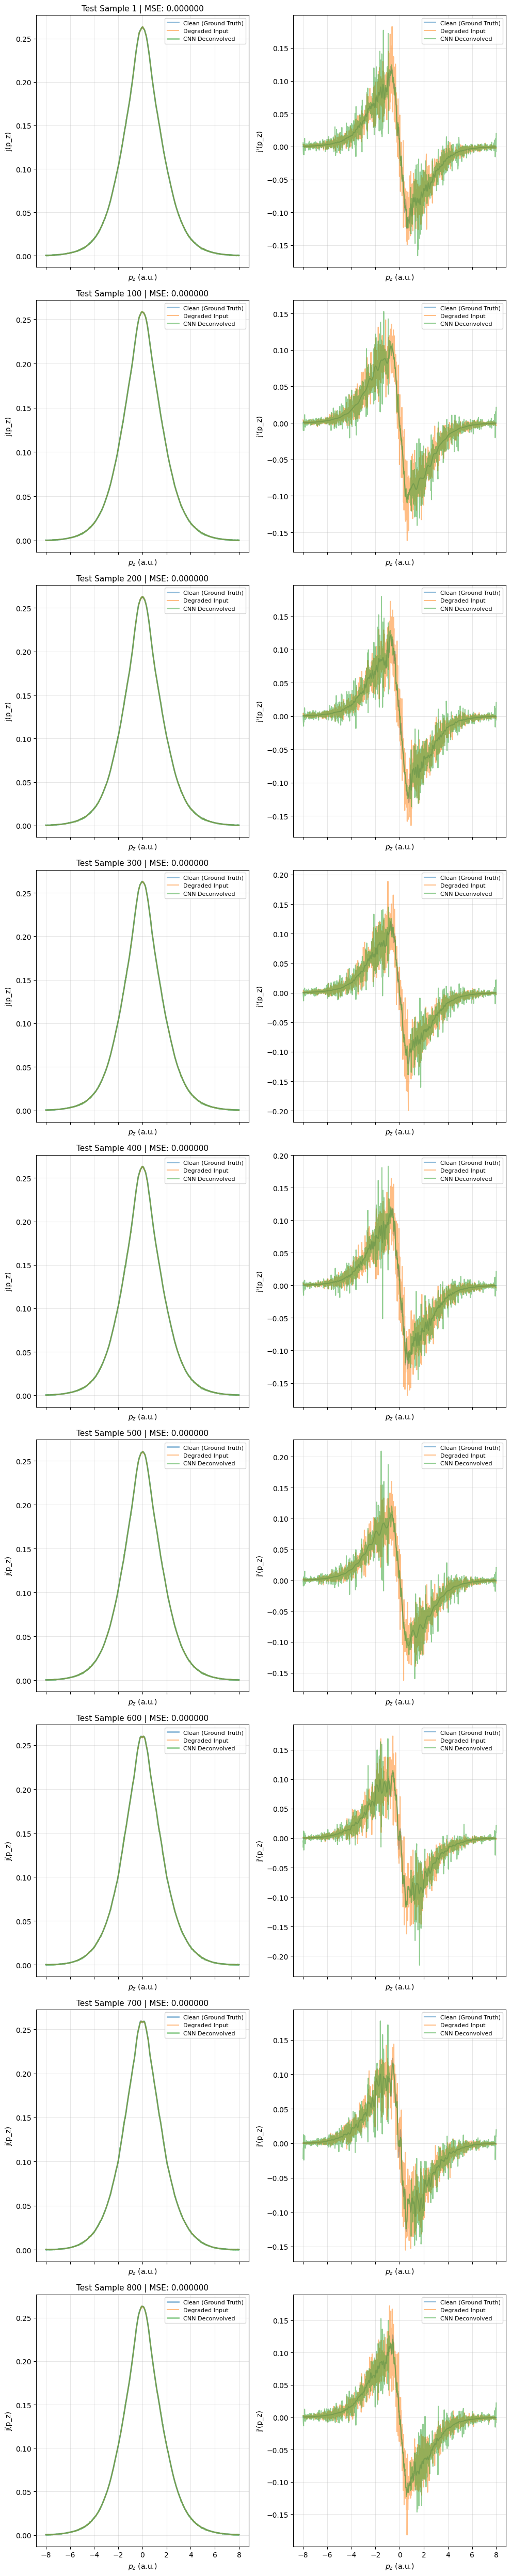

In [44]:
%matplotlib inline
# Evaluate on test set
model_unet.eval()

with torch.no_grad():
    # Get predictions for all test samples
    test_predictions = model_unet(X_test).numpy()
    test_clean = y_test.numpy()
    test_degraded = X_test.numpy()
    
    # Calculate metrics
    mse_per_sample = np.mean((test_predictions - test_clean)**2, axis=1)
    mae_per_sample = np.mean(np.abs(test_predictions - test_clean), axis=1)
    
    print("\n" + "=" * 60)
    print("TEST SET EVALUATION")
    print("=" * 60)
    print(f"Number of test samples: {len(test_predictions)}")
    print(f"Average MSE: {np.mean(mse_per_sample):.6f}")
    print(f"Average MAE: {np.mean(mae_per_sample):.6f}")
    print(f"Std MSE: {np.std(mse_per_sample):.6f}")
    print(f"Min MSE: {np.min(mse_per_sample):.6f}")
    print(f"Max MSE: {np.max(mse_per_sample):.6f}")
    print("=" * 60)

# Plot 9 examples from test set
fig, axs = plt.subplots(9, 2, figsize=(10, 50), sharex=True)


n_display = min(9, len(test_predictions))
display_indices = np.linspace(0, len(test_predictions)-1, n_display, dtype=int)

for i, idx in enumerate(display_indices):
    axs[i,0].plot(pz_sample, test_clean[idx], label='Clean (Ground Truth)', 
            linewidth=2, alpha=0.5)
    axs[i,0].plot(pz_sample, test_degraded[idx], label='Degraded Input', 
            linewidth=1.5, alpha=0.5)
    axs[i,0].plot(pz_sample, test_predictions[idx], label='CNN Deconvolved', 
            linewidth=2, alpha=0.5)
    
    axs[i,0].set_title(f'Test Sample {idx+1} | MSE: {mse_per_sample[idx]:.6f}', 
                fontsize=11)
    axs[i,0].set_xlabel('$p_z$ (a.u.)', fontsize=10)
    axs[i,0].set_ylabel('j(p_z)', fontsize=10)
    axs[i,0].legend(fontsize=8, loc='best')
    axs[i,0].grid(True, alpha=0.3)
    
    # plot derivatives
    axs[i,1].plot(pz_sample, np.gradient(test_clean[idx], pz_sample), label='Clean (Ground Truth)', alpha = 0.5)
    axs[i,1].plot(pz_sample, np.gradient(test_degraded[idx], pz_sample), label='Degraded Input', alpha = 0.5)
    axs[i,1].plot(pz_sample, np.gradient(test_predictions[idx], pz_sample), label='CNN Deconvolved', alpha = 0.5)
    axs[i,1].set_xlabel('$p_z$ (a.u.)', fontsize=10)
    axs[i,1].set_ylabel("j'(p_z)", fontsize=10)
    axs[i,1].legend(fontsize=8, loc='best')
    axs[i,1].grid(True, alpha=0.3)
    

plt.tight_layout()
plt.show()

C:\Users\Jpjha\AppData\Local\Temp\ipykernel_34408\2829822014.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  current_area = np.trapz(cp, pz)


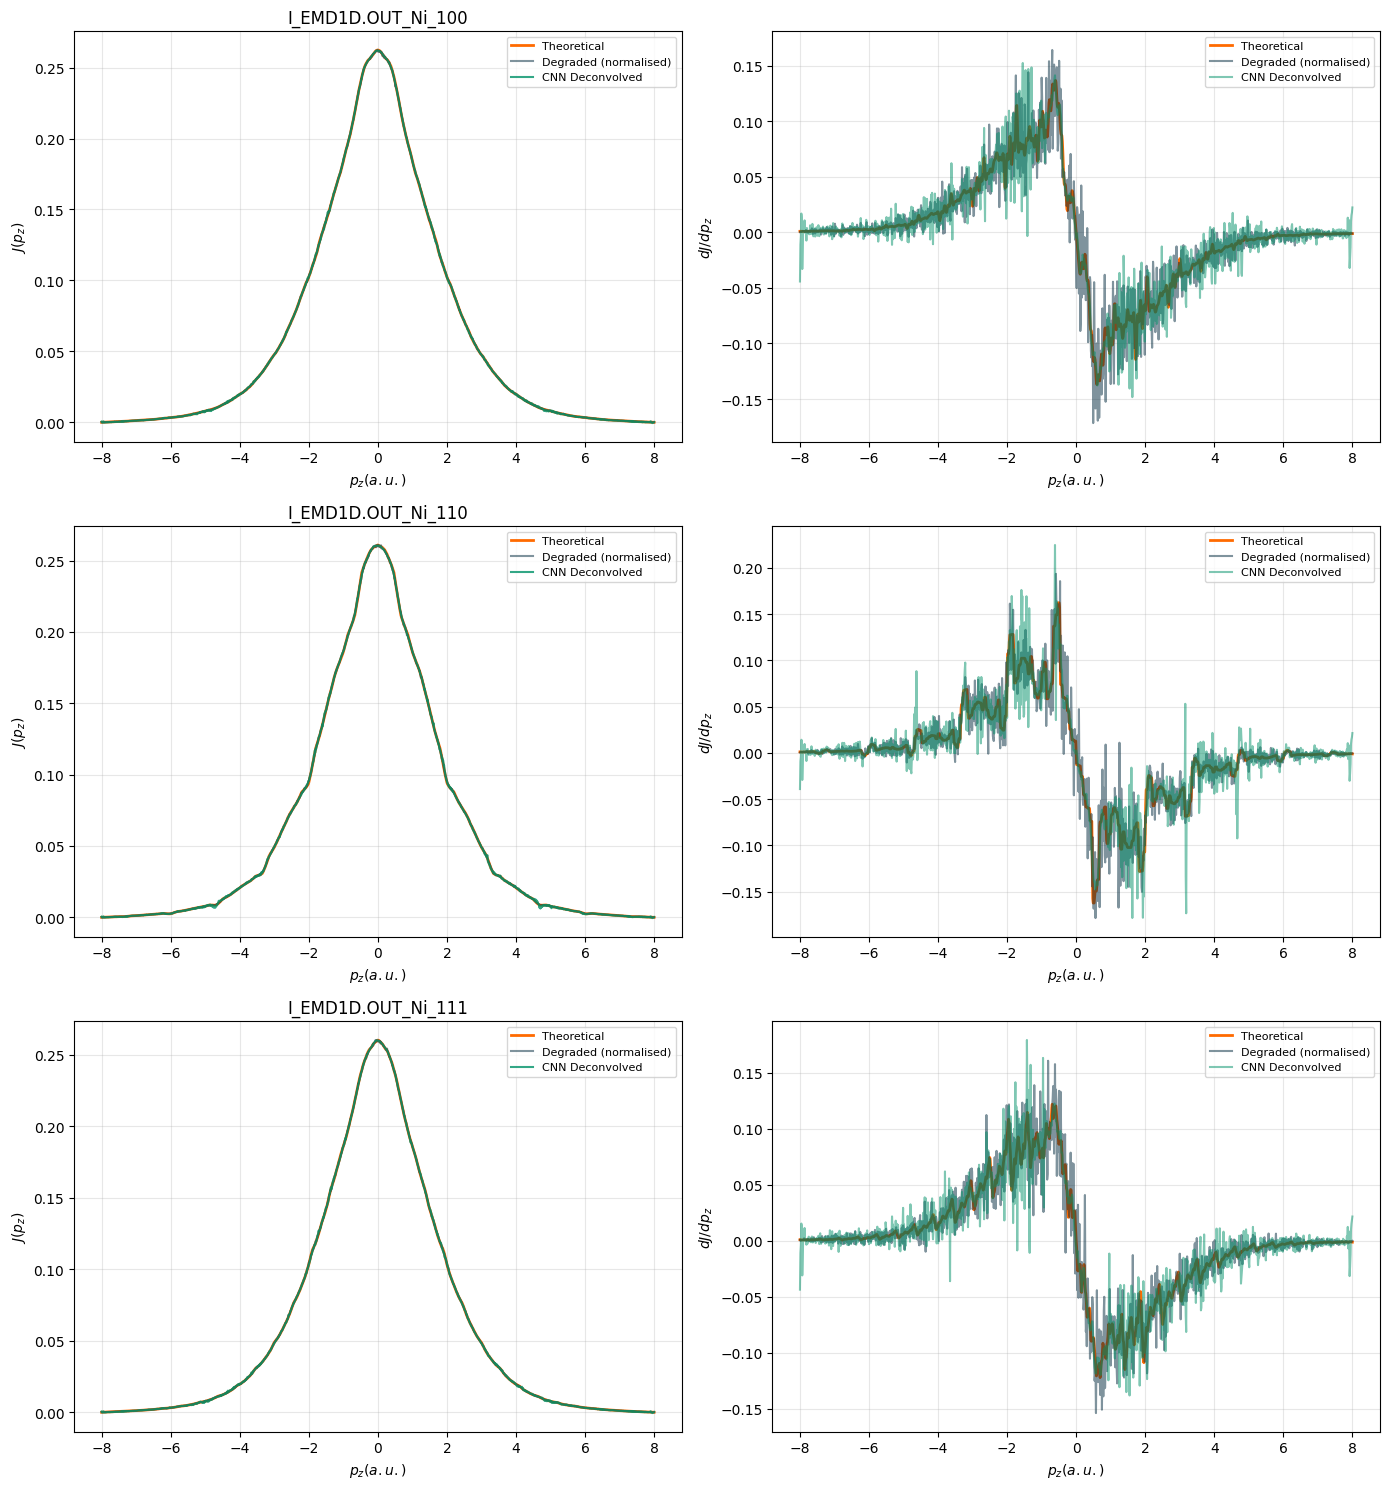

In [45]:
%matplotlib inline
model_unet.eval()

fig, axs = plt.subplots(len(dataframes), 2, figsize=(14, 5 * len(dataframes)))
if len(dataframes) == 1:
    axs = axs[np.newaxis, :]

with torch.no_grad():
    for i, (key, df) in enumerate(dataframes.items()):
        pz_local = df['p_z'].values
        theoretical = df['Theory J(p_z)'].values
        degraded = df['Degraded Theory J(p_z)'].values

        # Normalise the degraded profile before feeding into the model
        degraded_norm = normalise(pz_local, degraded, area_under_curve=1)

        # Pass through model
        input_tensor = torch.FloatTensor(degraded_norm).unsqueeze(0)
        deconvolved = model_unet(input_tensor).squeeze(0).numpy()

        # Also normalise theoretical for fair comparison
        theoretical_norm = normalise(pz_local, theoretical, area_under_curve=1)


        # Plot profiles
        axs[i, 0].plot(pz_local, theoretical_norm, color = "#ff6a00", label='Theoretical', linewidth=2)
        axs[i, 0].plot(pz_local, degraded_norm, color = "#00293c", label='Degraded (normalised)', alpha=0.5)
        axs[i, 0].plot(pz_local, deconvolved, color = "#009168", label='CNN Deconvolved', linewidth=1.5, alpha=0.8)
        axs[i, 0].set_title(key, fontsize=12)
        axs[i, 0].set_xlabel('$p_z (a.u.)$')
        axs[i, 0].set_ylabel('$J(p_z)$')
        axs[i, 0].legend(fontsize=8)
        axs[i, 0].grid(True, alpha=0.3)

        # Plot derivatives
        axs[i, 1].plot(pz_local, np.gradient(theoretical_norm, pz_local), color = "#ff6a00", label='Theoretical', linewidth=2)
        axs[i, 1].plot(pz_local, np.gradient(degraded_norm, pz_local), color = "#00293c", alpha=0.5, label='Degraded (normalised)')
        axs[i, 1].plot(pz_local, np.gradient(deconvolved, pz_local), color = "#009168", label='CNN Deconvolved', linewidth=1.5, alpha=0.5)
        axs[i, 1].set_xlabel('$p_z (a.u.)$')
        axs[i, 1].set_ylabel("$dJ/dp_z$")
        axs[i, 1].legend(fontsize=8)
        axs[i, 1].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()